<a href="https://colab.research.google.com/github/Yellowcrocodile50/DF_Project/blob/main/DF_Classification_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

In [2]:
# 데이터 가져오기
df = pd.read_csv('heart.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [3]:
# 데이터 타입 확인
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [4]:
# 기초 통계량 확인
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [5]:
# 결측 데이터 확인
df.isna().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [6]:
# 전체 shape 확인
df.shape

(1025, 14)

In [7]:
# 시각화 진행
import matplotlib.pyplot as plt
import seaborn as sns

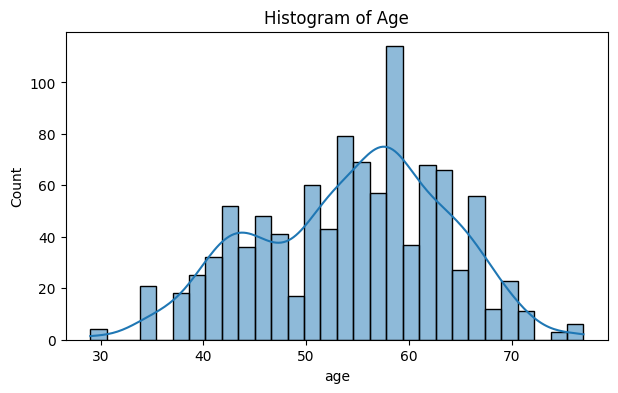

In [8]:
# 수치형 데이터들의 분포를 보기 위한 히스토그램

# 나이(age) 히스토그램 (교재 p.672)
plt.figure(figsize=(7, 4))
sns.histplot(x='age', data=df, bins=30, kde=True)
plt.title('Histogram of Age')
plt.show()

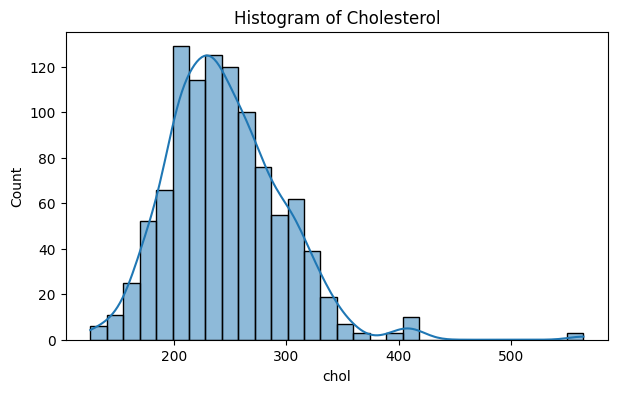

In [9]:
# 콜레스테롤(chol) 히스토그램 (교재 p.672)
plt.figure(figsize=(7, 4))
sns.histplot(x='chol', data=df, bins=30, kde=True)
plt.title('Histogram of Cholesterol')
plt.show()

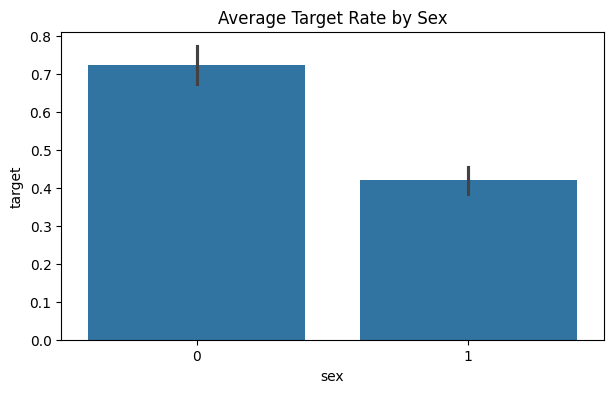

In [10]:
# 범주형 데이터들의 분포를 보기 위한 막대 그래프 (바 플롯)

# 성별과 심장병 발생률 간의 막대 그래프(교재 p.677)
# sex 1: 남성 / sex 0: 여성
plt.figure(figsize=(7, 4))
sns.barplot(x='sex', y='target', data=df)
plt.title('Average Target Rate by Sex')
plt.show()

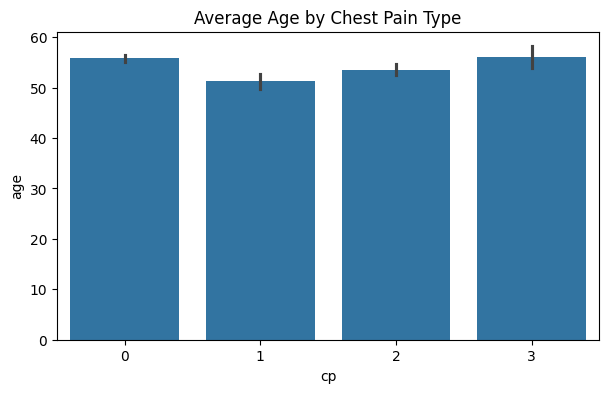

In [11]:
## 가슴통증과 평균 나이간의 막대 그래프(교재 p.677)
plt.figure(figsize=(7, 4))
sns.barplot(x='cp', y='age', data=df)
plt.title('Average Age by Chest Pain Type')
plt.show()

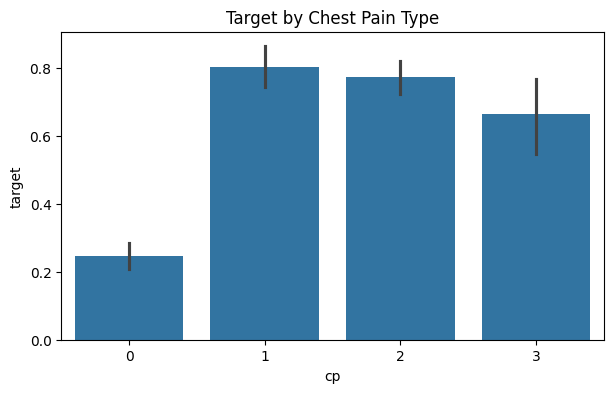

In [12]:
## 가슴통증과 심장병 발생간의 막대 그래프(교재 p.677)
plt.figure(figsize=(7, 4))
sns.barplot(x='cp', y='target', data=df)
plt.title('Target by Chest Pain Type')
plt.show()

In [13]:
# 종속변수, 독립변수 설정

# 종속 변수 Y: 심장병 발병 여부 (target)
Y = df['target']

# 독립 변수 X: 가슴 통증 (cp)
X = df['cp']

# **(참고사항) 의학 데이터에서의 cp의 의미**
# **cp 0 (전형적인 협심증):** 가슴을 짓누르거나 쥐어짜는 듯한 '클래식한' 심장 통증
# **cp 1 (비전형적 협심증):** 찌르는 듯하게 가슴이 아픈 경우
# **cp 2 (비협심증성 통증):** 근육통, 소화불량, 스트레스 등 다른 이유로 가슴이 아픈 경우
# **cp 3 (무증상):** 가슴 통증을 거의 느끼지 못하는 상태

In [14]:
# 새로운 독립변수 설정 - 가슴통증 위험

def cp_risk_group(cp):
    if cp == 0:
        return 'high_risk'    # cp 0 - 고위험군
    elif cp in [1, 2]:
        return 'mid_risk'     # cp 1, 2 - 중위험군
    else:
        return 'low_risk'     # cp 3 - 저위험군

df['cp_risk_group'] = df['cp'].apply(cp_risk_group)

# 간략한 결과 확인
df[['cp', 'cp_risk_group', 'target']].head(10)

,cp,cp_risk_group,target
0,0,high_risk,0
1,0,high_risk,0
2,0,high_risk,0
3,0,high_risk,0
4,0,high_risk,0
5,0,high_risk,1
6,0,high_risk,0
7,0,high_risk,0
8,0,high_risk,0
9,0,high_risk,0


In [15]:
# 새로운 데이터프레임 저장

df_final = df.copy()

df_final = df_final.drop(columns=['cp'])

# cp가 없어졌는지 확인
df_final.head(2)

,age,sex,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,cp_risk_group
0,52,1,125,212,0,1,168,0,1.0,2,2,3,0,high_risk
1,53,1,140,203,1,0,155,1,3.1,0,0,3,0,high_risk


In [16]:
# 새로운 데이터프레임으로 저장 완료
df_final.to_csv('heart_final_preprocessed.csv', index=False)

In [17]:
print("thal unique:", sorted(df['thal'].unique()))

thal unique: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


In [18]:
df['thal'].value_counts().sort_index()

,count
thal,
0,7
1,64
2,544
3,410


In [19]:
# 데이터 인코딩
import numpy as np
from sklearn.preprocessing import LabelEncoder

# 1. 레이블 인코딩 대상: cp_risk_group & slope (위험도 의미 부여)
encoder_risk = LabelEncoder()
encoder_risk.classes_ = np.array(['low_risk', 'mid_risk', 'high_risk'])
df['cp_risk_encoded'] = encoder_risk.transform(df['cp_risk_group'])
print('인코딩 클래스:', encoder_risk.classes_)

# slope는 실제로 0 1 2와 위험도가 비례하기 때문에 레이블 인코딩이 실제로 필요하진 않음

# 확인
df[['cp_risk_group', 'cp_risk_encoded', 'target']].head(10)

인코딩 클래스: ['low_risk' 'mid_risk' 'high_risk']


,cp_risk_group,cp_risk_encoded,target
0,high_risk,2,0
1,high_risk,2,0
2,high_risk,2,0
3,high_risk,2,0
4,high_risk,2,0
5,high_risk,2,1
6,high_risk,2,0
7,high_risk,2,0
8,high_risk,2,0
9,high_risk,2,0


In [20]:
# 2. 원핫 인코딩 대상: restecg & thal
import numpy as np
from sklearn.preprocessing import OneHotEncoder

#restecg(안정 시 심전도 결과)
restecg_items = np.array(df['restecg']).reshape(-1, 1)

oh_encoder_restecg = OneHotEncoder()
oh_encoder_restecg.fit(restecg_items)
oh_labels_restecg = oh_encoder_restecg.transform(restecg_items)

#thal(검사 결과 (혈류 상태))
# 1. thal 컬럼에서 값이 0인 이상치 행 삭제 및 인덱스 초기화
df = df[df['thal'] != 0].reset_index(drop=True)

thal_items = np.array(df['thal']).reshape(-1, 1)

oh_encoder_thal = OneHotEncoder()
oh_labels_thal = oh_encoder_thal.fit_transform(thal_items)
oh_labels_thal = oh_encoder_thal.transform(thal_items)

restecg_df = pd.DataFrame(oh_labels_restecg.toarray(), columns=oh_encoder_restecg.get_feature_names_out(['restecg']))
thal_df = pd.DataFrame(oh_labels_thal.toarray(), columns=oh_encoder_thal.get_feature_names_out(['thal']))

df = pd.concat([df, restecg_df, thal_df], axis=1)

# 확인
df.head(3)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,...,thal,target,cp_risk_group,cp_risk_encoded,restecg_0,restecg_1,restecg_2,thal_1,thal_2,thal_3
0,52.0,1.0,0.0,125.0,212.0,0.0,1.0,168.0,0.0,1.0,...,3.0,0.0,high_risk,2.0,0.0,1.0,0.0,0.0,0.0,1.0
1,53.0,1.0,0.0,140.0,203.0,1.0,0.0,155.0,1.0,3.1,...,3.0,0.0,high_risk,2.0,1.0,0.0,0.0,0.0,0.0,1.0
2,70.0,1.0,0.0,145.0,174.0,0.0,1.0,125.0,1.0,2.6,...,3.0,0.0,high_risk,2.0,0.0,1.0,0.0,0.0,0.0,1.0


In [21]:
# 3. 더미 인코딩 대상: sex & fbs & exang
df_dummy = pd.get_dummies(df, columns=['sex', 'fbs', 'exang'], drop_first=True)
dummy_cols = [col for col in df_dummy.columns if any(x in col for x in ['sex_', 'fbs_', 'exang_'])]

# 확인
display(df_dummy[dummy_cols].head())


print(f"\n최종 컬럼 개수: {len(df_final.columns)}")
print(df_final.columns.tolist())


,sex_1.0,fbs_1.0,exang_1.0
0,True,False,False
1,True,True,True
2,True,False,True
3,True,False,False
4,False,True,False



최종 컬럼 개수: 14
['age', 'sex', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target', 'cp_risk_group']


In [22]:
# [1단계] 더미 인코딩 (결과를 df에 바로 덮어씌우거나 df_final로 시작합니다)
# 여기서 drop_first=True를 했으므로 T/F 형태의 새로운 컬럼들이 생깁니다.
df_final = pd.get_dummies(df, columns=['sex', 'fbs', 'exang'], drop_first=True)

# [2단계] 원본 컬럼 삭제 (이미 인코딩된 것들)
# 주의: 여기서 'df'가 아니라 위에서 만든 'df_final'을 사용해야 합니다!
columns_to_drop = ['thal', 'restecg', 'cp', 'cp_risk_group', 'slope']
df_final = df_final.drop(columns=columns_to_drop, errors='ignore')

# [3단계] 중복 제거 및 확인
df_final = df_final.loc[:, ~df_final.columns.duplicated()]

print("--- 최종 데이터 구성 ---")
print(df_final.columns.tolist())
display(df_final.head()) # 이제 여기서 T/F로 보일 거예요!

--- 최종 데이터 구성 ---
['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca', 'target', 'cp_risk_encoded', 'restecg_0', 'restecg_1', 'restecg_2', 'thal_1', 'thal_2', 'thal_3', 'sex_1.0', 'fbs_1.0', 'exang_1.0']


,age,trestbps,chol,thalach,oldpeak,ca,target,cp_risk_encoded,restecg_0,restecg_1,restecg_2,thal_1,thal_2,thal_3,sex_1.0,fbs_1.0,exang_1.0
0,52.0,125.0,212.0,168.0,1.0,2.0,0.0,2.0,0.0,1.0,0.0,0.0,0.0,1.0,True,False,False
1,53.0,140.0,203.0,155.0,3.1,0.0,0.0,2.0,1.0,0.0,0.0,0.0,0.0,1.0,True,True,True
2,70.0,145.0,174.0,125.0,2.6,0.0,0.0,2.0,0.0,1.0,0.0,0.0,0.0,1.0,True,False,True
3,61.0,148.0,203.0,161.0,0.0,1.0,0.0,2.0,0.0,1.0,0.0,0.0,0.0,1.0,True,False,False
4,62.0,138.0,294.0,106.0,1.9,3.0,0.0,2.0,0.0,1.0,0.0,0.0,1.0,0.0,False,True,False


In [23]:
# df_final 전체에서 결측치 개수 확인
print("--- 컬럼별 결측치(NaN) 개수 ---")
print(df_final.isnull().sum())

# 특히 y값(target)에 NaN이 있는지 확인
print(f"\ntarget 컬럼의 결측치 수: {df_final['target'].isnull().sum()}개")

--- 컬럼별 결측치(NaN) 개수 ---
age                7
trestbps           7
chol               7
thalach            7
oldpeak            7
ca                 7
target             7
cp_risk_encoded    7
restecg_0          0
restecg_1          0
restecg_2          0
thal_1             7
thal_2             7
thal_3             7
sex_1.0            0
fbs_1.0            0
exang_1.0          0
dtype: int64

target 컬럼의 결측치 수: 7개


In [24]:
# 1. 결측치가 하나라도 있는 행은 모두 삭제합니다.
df_final = df_final.dropna()

# 2. 삭제 후 인덱스를 다시 정렬해줍니다 (인덱스 꼬임 방지)
df_final = df_final.reset_index(drop=True)

In [25]:
# 모든 X,Y 변수 새로운 데이터프레임으로 추출
import pandas as pd
from sklearn.model_selection import train_test_split

y = df_final['target']
X = df_final.drop(columns=['target'])

# train test 8:2 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0, shuffle=True)

# 4. 결과 확인
print("--- 데이터 추출 및 분리 완료 ---")
print(f"전체 피처(X) 개수: {X.shape[1]}개")
print(f"학습 데이터 크기 (X_train): {X_train.shape}")
print(f"테스트 데이터 크기 (X_test): {X_test.shape}")

# 데이터 일부 확인
display(X_train.head())
display(X_test.head())
display(y_train.head())
display(y_test.head())

--- 데이터 추출 및 분리 완료 ---
전체 피처(X) 개수: 16개
학습 데이터 크기 (X_train): (814, 16)
테스트 데이터 크기 (X_test): (204, 16)


,age,trestbps,chol,thalach,oldpeak,ca,cp_risk_encoded,restecg_0,restecg_1,restecg_2,thal_1,thal_2,thal_3,sex_1.0,fbs_1.0,exang_1.0
784,54.0,110.0,239.0,126.0,2.8,1.0,2.0,1.0,0.0,0.0,0.0,0.0,1.0,True,False,True
204,42.0,148.0,244.0,178.0,0.8,2.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,True,False,False
240,67.0,152.0,212.0,150.0,0.8,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,True,False,False
5,58.0,100.0,248.0,122.0,1.0,0.0,2.0,1.0,0.0,0.0,0.0,1.0,0.0,False,False,False
356,48.0,122.0,222.0,186.0,0.0,0.0,2.0,1.0,0.0,0.0,0.0,1.0,0.0,True,False,False


,age,trestbps,chol,thalach,oldpeak,ca,cp_risk_encoded,restecg_0,restecg_1,restecg_2,thal_1,thal_2,thal_3,sex_1.0,fbs_1.0,exang_1.0
478,51.0,140.0,298.0,122.0,4.2,3.0,2.0,1.0,0.0,0.0,0.0,0.0,1.0,True,False,True
635,58.0,130.0,197.0,131.0,0.6,0.0,2.0,1.0,0.0,0.0,0.0,1.0,0.0,False,False,False
247,39.0,138.0,220.0,152.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,False,False,False
783,62.0,120.0,281.0,103.0,1.4,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,True,False,False
27,56.0,130.0,256.0,142.0,0.6,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,True,True,True


,target
784,0.0
204,1.0
240,0.0
5,1.0
356,1.0


,target
478,0.0
635,1.0
247,1.0
783,0.0
27,0.0


In [26]:
import pandas as pd
import warnings
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')

# 1. 데이터 준비
X = df_final.drop(columns=['target'])
y = df_final['target']

# 2. 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0, shuffle=True)

# 3. 랜덤 포레스트 학습 및 예측 성능 평가
rf_clf = RandomForestClassifier(n_estimators=100, random_state=0, max_depth=5)
rf_clf.fit(X_train, y_train)

# 4. 예측 수행
pred = rf_clf.predict(X_test)
accuracy = accuracy_score(y_test, pred)

print('랜덤 포레스트 정확도: {0:.4f}'.format(accuracy))

랜덤 포레스트 정확도: 0.9363


In [27]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# 1. 결정 트리 모델 생성 및 학습
# 랜덤 포레스트와 비교를 위해 동일하게 random_state=0을 입력
dt_clf = DecisionTreeClassifier(random_state=0, max_depth=5)
dt_clf.fit(X_train, y_train)

# 2. 예측 수행
dt_pred = dt_clf.predict(X_test)

# 3. 정확도 평가
dt_accuracy = accuracy_score(y_test, dt_pred)

print('결정 트리 정확도: {0:.4f}'.format(dt_accuracy))

결정 트리 정확도: 0.9167


In [28]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold
import numpy as np
import pandas as pd

# 1. 데이터 준비
features = df_final.drop(columns=['target']).values # 넘파이 변환을 위해 .values 사용
label = df_final['target'].values

# 2. 모델 설정 (랜덤 포레스트)
# 과적합 방지를 위해 max_depth를 5로 설정하고 돌림
rf_clf = RandomForestClassifier(n_estimators=100, random_state=0, max_depth=5)

# 3. K-Fold 설정 (5개 폴드)
kfold = KFold(n_splits=5, shuffle=True, random_state=0)
cv_accuracy = []

print('심장병 데이터 세트 크기:', features.shape[0])

n_iter = 0

# 4. K-Fold 교차 검증 수행
for train_index, test_index in kfold.split(features):
    # 인덱스를 사용하여 학습용, 검증용 데이터 추출
    X_train, X_test = features[train_index], features[test_index]
    y_train, y_test = label[train_index], label[test_index]

    # 학습 및 예측
    rf_clf.fit(X_train, y_train)
    pred = rf_clf.predict(X_test)
    n_iter += 1

    # 반복 시마다 정확도 측정
    accuracy = np.round(accuracy_score(y_test, pred), 4)
    train_size = X_train.shape[0]
    test_size = X_test.shape[0]

    print('\n#{0} 교차 검증 정확도 :{1}, 학습 데이터 크기: {2}, 검증 데이터 크기: {3}'.format(n_iter, accuracy, train_size, test_size))
    cv_accuracy.append(accuracy)

# 5. 평균 검증 정확도 계산
print('\n## 최종 평균 검증 정확도:', np.mean(cv_accuracy))

심장병 데이터 세트 크기: 1018

#1 교차 검증 정확도 :0.9314, 학습 데이터 크기: 814, 검증 데이터 크기: 204

#2 교차 검증 정확도 :0.8725, 학습 데이터 크기: 814, 검증 데이터 크기: 204

#3 교차 검증 정확도 :0.9069, 학습 데이터 크기: 814, 검증 데이터 크기: 204

#4 교차 검증 정확도 :0.9064, 학습 데이터 크기: 815, 검증 데이터 크기: 203

#5 교차 검증 정확도 :0.9064, 학습 데이터 크기: 815, 검증 데이터 크기: 203

## 최종 평균 검증 정확도: 0.90472


In [29]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import StratifiedKFold
import numpy as np
import pandas as pd

# 1. 데이터 준비
X = df_final.drop(columns=['target']).values
y = df_final['target'].astype(int).values

# 2. 모델 설정
rf_clf = RandomForestClassifier(n_estimators=100, random_state=0, max_depth=5)

# 3. Stratified K-Fold 설정 (5개 폴드)
skfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
cv_accuracy = []

print(f'심장병 데이터 세트 전체 크기: {X.shape[0]}')

n_iter = 0

# 4. Stratified K-Fold 교차 검증 수행
for train_index, test_index in skfold.split(X, y):
    # 인덱스를 사용하여 학습용, 검증용 데이터 추출
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    # 학습 및 예측
    rf_clf.fit(X_train, y_train)
    pred = rf_clf.predict(X_test)

    # 반복 시마다 정확도 측정
    n_iter += 1
    accuracy = np.round(accuracy_score(y_test, pred), 4)
    train_size = X_train.shape[0]
    test_size = X_test.shape[0]

    # --- 출력 부분 최적화 ---
    print(f'\n#{n_iter} Stratified 교차 검증 정확도 : {accuracy}')
    print(f'   학습 데이터: {train_size}개, 검증 데이터: {test_size}개')

    # 레이블 분포를 사람이 읽기 편한 딕셔너리로 변환
    unique, counts = np.unique(y_test, return_counts=True)
    dist_dict = {int(k): int(v) for k, v in zip(unique, counts)}
    print(f'   # 검증 레이블(정답) 분포: {dist_dict}')

    cv_accuracy.append(accuracy)

# 5. 최종 결과 계산
print(f'\n## 최종 평균 검증 정확도: {np.round(np.mean(cv_accuracy), 4)}')

심장병 데이터 세트 전체 크기: 1018

#1 Stratified 교차 검증 정확도 : 0.9167
   학습 데이터: 814개, 검증 데이터: 204개
   # 검증 레이블(정답) 분포: {0: 99, 1: 105}

#2 Stratified 교차 검증 정확도 : 0.9216
   학습 데이터: 814개, 검증 데이터: 204개
   # 검증 레이블(정답) 분포: {0: 99, 1: 105}

#3 Stratified 교차 검증 정확도 : 0.9118
   학습 데이터: 814개, 검증 데이터: 204개
   # 검증 레이블(정답) 분포: {0: 99, 1: 105}

#4 Stratified 교차 검증 정확도 : 0.9212
   학습 데이터: 815개, 검증 데이터: 203개
   # 검증 레이블(정답) 분포: {0: 99, 1: 104}

#5 Stratified 교차 검증 정확도 : 0.8916
   학습 데이터: 815개, 검증 데이터: 203개
   # 검증 레이블(정답) 분포: {0: 99, 1: 104}

## 최종 평균 검증 정확도: 0.9126


In [30]:
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

# 1. 데이터 준비
X = df_final.drop(columns=['target'])
y = df_final['target'].astype(int)

# 학습/테스트 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y
)

# 2. 탐색할 파라미터 설정
# n_estimators: 나무의 개수
# max_depth: 나무의 최대 깊이
# min_samples_split: 노드를 분할하기 위한 최소 샘플 수
parameters = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5]
}

# 3. 모델 설정 및 GridSearchCV 객체 생성
rf_clf = RandomForestClassifier(random_state=0)
grid_rf = GridSearchCV(rf_clf, param_grid=parameters, cv=3, refit=True, n_jobs=-1)

# 4. 최적 파라미터 학습 및 결과 추출
grid_rf.fit(X_train, y_train)
scores_df = pd.DataFrame(grid_rf.cv_results_)

# 결과 리포트 출력
print('--- GridSearchCV 탐색 결과 ---')
display(scores_df[['params', 'mean_test_score', 'rank_test_score']])

print(f'\nGridSearchCV 최적 파라미터: {grid_rf.best_params_}')
print(f'GridSearchCV 최고 정확도(CV): {grid_rf.best_score_:.4f}')

# 5. 최적의 모델로 실제 테스트 데이터 예측
best_rf = grid_rf.best_estimator_
pred = best_rf.predict(X_test)
test_accuracy = accuracy_score(y_test, pred)

print(f'\n[최종 결과] 테스트 데이터 세트 정확도: {test_accuracy:.4f}')

--- GridSearchCV 탐색 결과 ---


,params,mean_test_score,rank_test_score
0,"{'max_depth': 3, 'min_samples_split': 2, 'n_es...",0.858711,9
1,"{'max_depth': 3, 'min_samples_split': 2, 'n_es...",0.855021,11
2,"{'max_depth': 3, 'min_samples_split': 5, 'n_es...",0.858711,9
3,"{'max_depth': 3, 'min_samples_split': 5, 'n_es...",0.855021,11
4,"{'max_depth': 5, 'min_samples_split': 2, 'n_es...",0.898049,5
5,"{'max_depth': 5, 'min_samples_split': 2, 'n_es...",0.891904,8
6,"{'max_depth': 5, 'min_samples_split': 5, 'n_es...",0.895594,6
7,"{'max_depth': 5, 'min_samples_split': 5, 'n_es...",0.893134,7
8,"{'max_depth': 7, 'min_samples_split': 2, 'n_es...",0.942257,2
9,"{'max_depth': 7, 'min_samples_split': 2, 'n_es...",0.948389,1



GridSearchCV 최적 파라미터: {'max_depth': 7, 'min_samples_split': 2, 'n_estimators': 100}
GridSearchCV 최고 정확도(CV): 0.9484

[최종 결과] 테스트 데이터 세트 정확도: 0.9706


In [31]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

def get_clf_eval(y_test, pred):
  confusion = confusion_matrix(y_test, pred)
  accuracy = accuracy_score(y_test, pred)
  precision = precision_score(y_test, pred)
  recall = recall_score(y_test, pred)
  f1 = f1_score(y_test, pred)
  roc_auc = roc_auc_score(y_test, pred)

  print("오차 행렬")
  print(confusion)
  print('정확도: {0:.4f}, 정밀도: {1:.4f}, 재현율: {2:.4f}, F1: {3:.4f}, AUC: {4:.4f}'.format(accuracy,precision,recall,f1, roc_auc))

import pandas as pd
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(n_estimators=100, random_state=0, max_depth=5)

rf_clf.fit(X_train, y_train)

pred - rf_clf.predict(X_test)
get_clf_eval(y_test, pred)

오차 행렬
[[ 95   4]
 [  2 103]]
정확도: 0.9706, 정밀도: 0.9626, 재현율: 0.9810, F1: 0.9717, AUC: 0.9703


In [32]:
import numpy as np

pred_proba = rf_clf.predict_proba(X_test)
pred = rf_clf.predict(X_test)
print('pred_proba()결과 Shape: {0}'.format(pred_proba.shape))
print('pred_proba array에서 앞 3개만 샘플로 추출 \n:', pred_proba[:3])

pred_proba_result = np.concatenate([pred_proba, pred.reshape(-1, 1)], axis=1)
print('2개의 클래스 중에서 더 큰 확률을 클래스 값으로 예측 \n'), pred_proba_result[:3]

pred_proba()결과 Shape: (204, 2)
pred_proba array에서 앞 3개만 샘플로 추출 
: [[0.97760868 0.02239132]
 [0.54825691 0.45174309]
 [0.29923208 0.70076792]]
2개의 클래스 중에서 더 큰 확률을 클래스 값으로 예측 



(None,
 array([[0.97760868, 0.02239132, 0.        ],
        [0.54825691, 0.45174309, 0.        ],
        [0.29923208, 0.70076792, 1.        ]]))

In [33]:
#정확도, 정밀도, 재현율, f1스코어 측정

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

def evaluate_model(model, X_test, y_test):
    pred = model.predict(X_test)

    print("오차 행렬:")
    print(confusion_matrix(y_test, pred))

    print(f"정확도: {accuracy_score(y_test, pred):.4f}")
    print(f"정밀도: {precision_score(y_test, pred):.4f}")
    print(f"재현율: {recall_score(y_test, pred):.4f}")
    print(f"F1-score: {f1_score(y_test, pred):.4f}")

evaluate_model(rf_clf, X_test, y_test)

#중요 지표: 재현율
#이유: 심장병 환자를 정상으로 잘못 판단하는 FN을 줄이는 것이 중요하기 때문


오차 행렬:
[[84 15]
 [ 9 96]]
정확도: 0.8824
정밀도: 0.8649
재현율: 0.9143
F1-score: 0.8889


In [34]:
#오차행렬, 예측 오류값, 예측 오류 유형 확인

from sklearn.metrics import confusion_matrix

# 예측
pred = rf_clf.predict(X_test)

# 오차 행렬 생성
confusion = confusion_matrix(y_test, pred)

# TN, FP, FN, TP 추출
tn, fp, fn, tp = confusion.ravel()

print("오차 행렬")
print(confusion)

print("\n--- 오차 행렬 해석 ---")
print(f"TN(True Negative): {tn}개 - 실제 정상(0)을 정상(0)으로 예측")
print(f"FP(False Positive): {fp}개 - 실제 정상(0)을 심장병(1)으로 잘못 예측")
print(f"FN(False Negative): {fn}개 - 실제 심장병(1)을 정상(0)으로 잘못 예측")
print(f"TP(True Positive): {tp}개 - 실제 심장병(1)을 심장병(1)으로 예측")

# 전체 예측 오류 수
total_error = fp + fn

print("\n--- 예측 오류 확인 ---")
print(f"전체 예측 오류 수: {total_error}개")
print(f"False Positive 오류 수: {fp}개")
print(f"False Negative 오류 수: {fn}개")

# 오류 유형 판단
print("\n--- 오류 유형 분석 ---")

if fp > fn:
    print("False Positive 오류가 더 많이 발생했습니다.")
    print("즉, 실제로는 정상인데 심장병이 있다고 잘못 예측하는 경우가 더 많습니다.")
elif fn > fp:
    print("False Negative 오류가 더 많이 발생했습니다.")
    print("즉, 실제로는 심장병이 있는데 정상이라고 잘못 예측하는 경우가 더 많습니다.")
else:
    print("False Positive와 False Negative 오류가 같은 수로 발생했습니다.")

오차 행렬
[[84 15]
 [ 9 96]]

--- 오차 행렬 해석 ---
TN(True Negative): 84개 - 실제 정상(0)을 정상(0)으로 예측
FP(False Positive): 15개 - 실제 정상(0)을 심장병(1)으로 잘못 예측
FN(False Negative): 9개 - 실제 심장병(1)을 정상(0)으로 잘못 예측
TP(True Positive): 96개 - 실제 심장병(1)을 심장병(1)으로 예측

--- 예측 오류 확인 ---
전체 예측 오류 수: 24개
False Positive 오류 수: 15개
False Negative 오류 수: 9개

--- 오류 유형 분석 ---
False Positive 오류가 더 많이 발생했습니다.
즉, 실제로는 정상인데 심장병이 있다고 잘못 예측하는 경우가 더 많습니다.


In [35]:
from sklearn.preprocessing import Binarizer

X = [[ 1, -1,  2],
     [ 2,  0,  0],
     [ 0,  1.1, 1.2]]

# threshold 기준값보다 같거나 작으면 0을, 크면 1을 반환
binarizer = Binarizer(threshold=1.1)
print(binarizer.fit_transform(X))

[[0. 0. 1.]
 [1. 0. 0.]
 [0. 0. 1.]]


In [36]:
# 테스트를 수행할 모든 임곗값을 리스트 객체로 저장.
thresholds = [0.4, 0.45, 0.50, 0.55, 0.60]

def get_eval_by_threshold(y_test , pred_proba_c1, thresholds):
    # thresholds list객체내의 값을 차례로 iteration하면서 Evaluation 수행.
    for custom_threshold in thresholds:
        binarizer = Binarizer(threshold=custom_threshold).fit(pred_proba_c1)
        custom_predict = binarizer.transform(pred_proba_c1)
        print('임계값:',custom_threshold)
        get_clf_eval(y_test , custom_predict)

get_eval_by_threshold(y_test ,pred_proba[:,1].reshape(-1,1), thresholds )

임계값: 0.4
오차 행렬
[[ 79  20]
 [  2 103]]
정확도: 0.8922, 정밀도: 0.8374, 재현율: 0.9810, F1: 0.9035, AUC: 0.8895
임계값: 0.45
오차 행렬
[[ 82  17]
 [  4 101]]
정확도: 0.8971, 정밀도: 0.8559, 재현율: 0.9619, F1: 0.9058, AUC: 0.8951
임계값: 0.5
오차 행렬
[[84 15]
 [ 9 96]]
정확도: 0.8824, 정밀도: 0.8649, 재현율: 0.9143, F1: 0.8889, AUC: 0.8814
임계값: 0.55
오차 행렬
[[92  7]
 [11 94]]
정확도: 0.9118, 정밀도: 0.9307, 재현율: 0.8952, F1: 0.9126, AUC: 0.9123
임계값: 0.6
오차 행렬
[[94  5]
 [12 93]]
정확도: 0.9167, 정밀도: 0.9490, 재현율: 0.8857, F1: 0.9163, AUC: 0.9176


In [37]:
from sklearn.metrics import precision_recall_curve

# 레이블 값이 1일때의 예측 확률을 추출
pred_proba_class1 = rf_clf.predict_proba(X_test)[:, 1]

# 실제값 데이터 셋과 레이블 값이 1일 때의 예측 확률을 precision_recall_curve 인자로 입력
precisions, recalls, thresholds = precision_recall_curve(y_test, pred_proba_class1 )
print('반환된 분류 결정 임곗값 배열의 Shape:', thresholds.shape)
print('반환된 precisions 배열의 Shape:', precisions.shape)
print('반환된 recalls 배열의 Shape:', recalls.shape)

print("thresholds 5 sample:", thresholds[:5])
print("precisions 5 sample:", precisions[:5])
print("recalls 5 sample:", recalls[:5])

#반환된 임계값 배열 로우가 147건이므로 샘플로 10건만 추출하되, 임곗값을 15 Step으로 추출.
thr_index = np.arange(0, thresholds.shape[0], 15)
print('샘플 추출을 위한 임계값 배열의 index 10개:', thr_index)
print('샘플용 10개의 임곗값: ', np.round(thresholds[thr_index], 2))

# 15 step 단위로 추출된 임계값에 따른 정밀도와 재현율 값
print('샘플 임계값별 정밀도: ', np.round(precisions[thr_index], 3))
print('샘플 임계값별 재현율: ', np.round(recalls[thr_index], 3))

반환된 분류 결정 임곗값 배열의 Shape: (174,)
반환된 precisions 배열의 Shape: (175,)
반환된 recalls 배열의 Shape: (175,)
thresholds 5 sample: [0.00692785 0.00956447 0.00972635 0.01266068 0.0127216 ]
precisions 5 sample: [0.51470588 0.51724138 0.51980198 0.52238806 0.525     ]
recalls 5 sample: [1. 1. 1. 1. 1.]
샘플 추출을 위한 임계값 배열의 index 10개: [  0  15  30  45  60  75  90 105 120 135 150 165]
샘플용 10개의 임곗값:  [0.01 0.03 0.08 0.14 0.22 0.45 0.61 0.7  0.8  0.84 0.91 0.96]
샘플 임계값별 정밀도:  [0.515 0.559 0.607 0.682 0.778 0.855 0.949 0.962 1.    1.    1.    1.   ]
샘플 임계값별 재현율:  [1.    1.    1.    1.    1.    0.952 0.886 0.733 0.581 0.429 0.276 0.095]


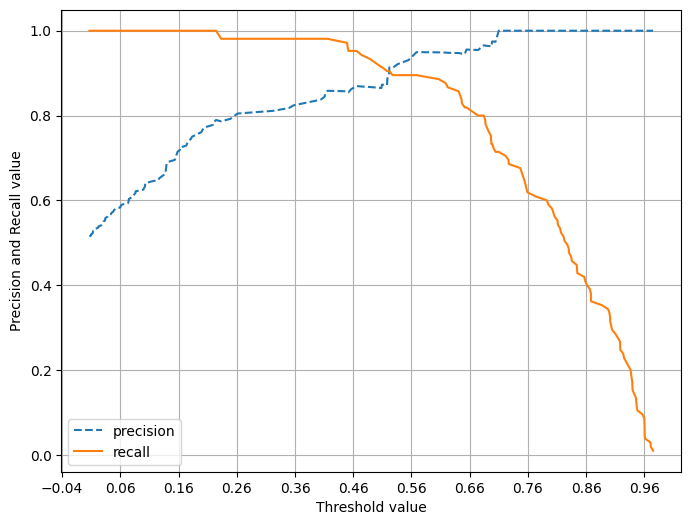

In [38]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
%matplotlib inline

def precision_recall_curve_plot(y_test , pred_proba_c1):
    # threshold ndarray와 이 threshold에 따른 정밀도, 재현율 ndarray 추출.
    precisions, recalls, thresholds = precision_recall_curve( y_test, pred_proba_c1)

    # X축을 threshold값으로, Y축은 정밀도, 재현율 값으로 각각 Plot 수행. 정밀도는 점선으로 표시
    plt.figure(figsize=(8,6))
    threshold_boundary = thresholds.shape[0]
    plt.plot(thresholds, precisions[0:threshold_boundary], linestyle='--', label='precision')
    plt.plot(thresholds, recalls[0:threshold_boundary],label='recall')

    # threshold 값 X 축의 Scale을 0.1 단위로 변경
    start, end = plt.xlim()
    plt.xticks(np.round(np.arange(start, end, 0.1),2))

    # x축, y축 label과 legend, 그리고 grid 설정
    plt.xlabel('Threshold value'); plt.ylabel('Precision and Recall value')
    plt.legend(); plt.grid()
    plt.show()

precision_recall_curve_plot( y_test, rf_clf.predict_proba(X_test)[:, 1] )

In [39]:
from sklearn.metrics import roc_curve

# 레이블 값이 1일때의 예측 확률을 추출
pred_proba_class1 = rf_clf.predict_proba(X_test)[:, 1]

fprs , tprs , thresholds = roc_curve(y_test, pred_proba_class1)
# 반환된 임곗값 배열에서 샘플로 데이터를 추출하되, 임곗값을 5 Step으로 추출.
# thresholds[0]은 max(예측확률)+1로 임의 설정됨. 이를 제외하기 위해 np.arange는 1부터 시작
thr_index = np.arange(1, thresholds.shape[0], 5)
print('샘플 추출을 위한 임곗값 배열의 index:', thr_index)
print('샘플 index로 추출한 임곗값: ', np.round(thresholds[thr_index], 2))

# 5 step 단위로 추출된 임계값에 따른 FPR, TPR 값
print('샘플 임곗값별 FPR: ', np.round(fprs[thr_index], 3))
print('샘플 임곗값별 TPR: ', np.round(tprs[thr_index], 3))

샘플 추출을 위한 임곗값 배열의 index: [ 1  6 11 16 21 26 31 36 41 46 51 56 61]
샘플 index로 추출한 임곗값:  [0.97 0.94 0.9  0.75 0.7  0.65 0.53 0.51 0.42 0.23 0.17 0.13 0.03]
샘플 임곗값별 FPR:  [0.    0.    0.    0.    0.03  0.051 0.091 0.141 0.172 0.283 0.394 0.545
 0.889]
샘플 임곗값별 TPR:  [0.01  0.181 0.314 0.648 0.733 0.819 0.895 0.914 0.981 0.981 1.    1.
 1.   ]


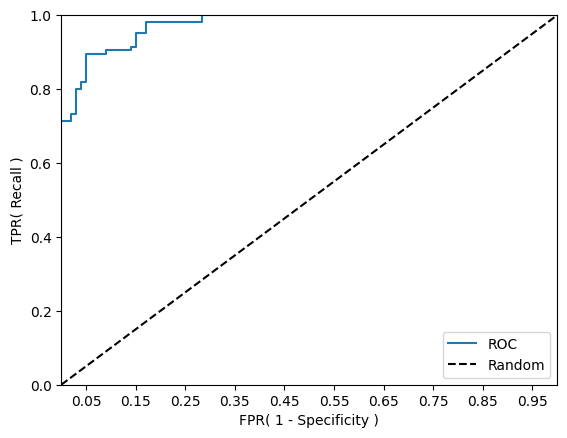

In [40]:
def roc_curve_plot(y_test , pred_proba_c1):
    # 임곗값에 따른 FPR, TPR 값을 반환 받음.
    fprs , tprs , thresholds = roc_curve(y_test ,pred_proba_c1)

    # ROC Curve를 plot 곡선으로 그림.
    plt.plot(fprs , tprs, label='ROC')
    # 가운데 대각선 직선을 그림.
    plt.plot([0, 1], [0, 1], 'k--', label='Random')

    # FPR X 축의 Scale을 0.1 단위로 변경, X,Y 축명 설정등
    start, end = plt.xlim()
    plt.xticks(np.round(np.arange(start, end, 0.1),2))
    plt.xlim(0,1); plt.ylim(0,1)
    plt.xlabel('FPR( 1 - Specificity )'); plt.ylabel('TPR( Recall )')
    plt.legend()
    plt.show()

roc_curve_plot(y_test, rf_clf.predict_proba(X_test)[:, 1] )

In [41]:
from sklearn.metrics import roc_auc_score
pred_proba = rf_clf.predict_proba(X_test)[:, 1]
roc_score = roc_auc_score(y_test, pred_proba)
print('ROC AUC 값: {0:.4f}'.format(roc_score))

ROC AUC 값: 0.9747


In [42]:
precisions, recalls, thresholds = precision_recall_curve(
    y_test,
    rf_clf.predict_proba(X_test)[:, 1]
)

prec_100_indices = np.where(precisions[:-1] >= 1.0)[0]

if len(prec_100_indices) > 0:
    best_idx = prec_100_indices[0]
    threshold_prec100 = thresholds[best_idx]
    print(f"정밀도 100% 달성 임계값: {threshold_prec100:.4f}")

y_pred_prec100 = (rf_clf.predict_proba(X_test)[:, 1] >= threshold_prec100).astype(int)

print(f"\n[정밀도 100% 결과 - 임계값 {threshold_prec100:.4f}]")
cm = confusion_matrix(y_test, y_pred_prec100)
print(f"오차 행렬:\n{cm}")
print(f"정밀도: {precision_score(y_test, y_pred_prec100):.4f}")
print(f"재현율: {recall_score(y_test, y_pred_prec100):.4f}")
print(f"F1    : {f1_score(y_test, y_pred_prec100):.4f}")
print(f"정확도: {accuracy_score(y_test, y_pred_prec100):.4f}")
print(f"\nFP = {cm[0,1]}  ← 0이면 정밀도 100% 달성")
print(f"FN = {cm[1,0]}  ← 놓친 실제 환자 수")

정밀도 100% 달성 임계값: 0.7099

[정밀도 100% 결과 - 임계값 0.7099]
오차 행렬:
[[99  0]
 [30 75]]
정밀도: 1.0000
재현율: 0.7143
F1    : 0.8333
정확도: 0.8529

FP = 0  ← 0이면 정밀도 100% 달성
FN = 30  ← 놓친 실제 환자 수


In [43]:
# ── 재현율 100% 임계값 찾기 ──────────────────────
precisions, recalls, thresholds = precision_recall_curve(
    y_test,
    rf_clf.predict_proba(X_test)[:, 1]
)

# 재현율이 1.0인 인덱스 중 정밀도가 가장 높은 지점 선택
rec_100_indices = np.where(recalls[:-1] >= 1.0)[0]

if len(rec_100_indices) > 0:
    best_idx = rec_100_indices[-1]           # 정밀도 최대 보존 지점 (가장 높은 임계값)
    threshold_rec100 = thresholds[best_idx]
    print(f"재현율 100% 달성 임계값: {threshold_rec100:.4f}")

y_pred_rec100 = (rf_clf.predict_proba(X_test)[:, 1] >= threshold_rec100).astype(int)

print(f"\n[재현율 100% 결과 - 임계값 {threshold_rec100:.4f}]")
cm = confusion_matrix(y_test, y_pred_rec100)
print(f"오차 행렬:\n{cm}")
print(f"정밀도: {precision_score(y_test, y_pred_rec100):.4f}")
print(f"재현율: {recall_score(y_test, y_pred_rec100):.4f}")
print(f"F1    : {f1_score(y_test, y_pred_rec100):.4f}")
print(f"정확도: {accuracy_score(y_test, y_pred_rec100):.4f}")
print(f"\nFP = {cm[0,1]}  ← 불필요하게 양성으로 분류된 수")
print(f"FN = {cm[1,0]}  ← 0이면 재현율 100% 달성")

재현율 100% 달성 임계값: 0.2243

[재현율 100% 결과 - 임계값 0.2243]
오차 행렬:
[[ 71  28]
 [  0 105]]
정밀도: 0.7895
재현율: 1.0000
F1    : 0.8824
정확도: 0.8627

FP = 28  ← 불필요하게 양성으로 분류된 수
FN = 0  ← 0이면 재현율 100% 달성


# **배깅의 대표방식 (랜덤 포레스트) 외에 Boosting 방식 적용**

In [44]:
# AUC 계산을 위해 3개의 인자(실제값, 예측값, 예측확률)를 받는 get_clf_eval 함수로 재정의
def get_clf_eval(y_actual, y_pred, y_prob):
    confusion = confusion_matrix(y_actual, y_pred)
    accuracy = accuracy_score(y_actual, y_pred)
    precision = precision_score(y_actual, y_pred)
    recall = recall_score(y_actual, y_pred)
    f1 = f1_score(y_actual, y_pred)
    roc_auc = roc_auc_score(y_actual, y_prob)

    print('\n# 평가 지표 결과 #')
    print('오차 행렬\n', confusion)
    print(f'정확도: {accuracy:.4f}, 정밀도: {precision:.4f}, 재현율: {recall:.4f}, F1: {f1:.4f}, AUC: {roc_auc:.4f}')

# XGBoost

In [45]:
import xgboost

print(xgboost.__version__)

3.2.0


In [46]:
from xgboost import XGBClassifier
from xgboost import plot_importance
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

# 데이터 중복 체크 및 제거
df_final = df_final.drop_duplicates()

# 데이터 분리 (Train:Test = 8:2)
X_features = df_final.drop(columns=['target'])
y_label = df_final['target']
X_train, X_test, y_train, y_test = train_test_split(X_features, y_label, test_size=0.2, random_state=0)

# 학습 데이터에서 다시 검증 데이터(Validation) 분리
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=0)

# XGBoost 모델 설정 및 학습
xgb_wrapper = XGBClassifier(
    n_estimators=400,
    learning_rate=0.1,
    max_depth=3,
    early_stopping_rounds=50,
    eval_metric="logloss"
)

evals = [(X_val, y_val)]
xgb_wrapper.fit(X_tr, y_tr, eval_set=evals, verbose=False)

# 최종 평가 (처음 보는 X_test로 평가)
preds = xgb_wrapper.predict(X_test)
pred_proba = xgb_wrapper.predict_proba(X_test)[:, 1]

get_clf_eval(y_test, preds, pred_proba)


# 평가 지표 결과 #
오차 행렬
 [[47 11]
 [ 4 49]]
정확도: 0.8649, 정밀도: 0.8167, 재현율: 0.9245, F1: 0.8673, AUC: 0.9317


In [47]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd
import warnings

warnings.filterwarnings('ignore')

# 데이터 준비 및 분할
X_features = df_final.drop(columns=['target'])
y_label = df_final['target']
X_train, X_test, y_train, y_test = train_test_split(X_features, y_label, test_size=0.2, random_state=0)

# XGBClassifier 객체 생성
xgb_model = XGBClassifier(n_estimators=100, random_state=0)

# 하이퍼파라미터 그리드 설정
param_grid = {
    'max_depth': [3, 5, 7],           # 트리의 최대 깊이
    'learning_rate': [0.01, 0.05, 0.1], # 학습률
    'min_child_weight': [1, 3, 5],    # 과적합 방지를 위한 최소 자식 가중치
    'colsample_bytree': [0.7, 0.8, 0.9] # 트리 구성 시 무작위 피처 선택 비율
}

# GridSearchCV 실행 (Stratified K-Fold 기반)
grid_cv = GridSearchCV(xgb_model, param_grid=param_grid, cv=3, scoring='roc_auc', n_jobs=-1)
grid_cv.fit(X_train, y_train)

print(f'최적 하이퍼파라미터: {grid_cv.best_params_}')
print(f'최고 AUC 점수: {grid_cv.best_score_:.4f}')

# 최적 모델로 예측 및 평가
best_xgb = grid_cv.best_estimator_
preds = best_xgb.predict(X_test)
pred_proba = best_xgb.predict_proba(X_test)[:, 1]

print('\n# XGBoost 최종 성능 평가 결과 #')
get_clf_eval(y_test, preds, pred_proba)

최적 하이퍼파라미터: {'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 7, 'min_child_weight': 1}
최고 AUC 점수: 0.9669

# XGBoost 최종 성능 평가 결과 #

# 평가 지표 결과 #
오차 행렬
 [[49  9]
 [ 3 50]]
정확도: 0.8919, 정밀도: 0.8475, 재현율: 0.9434, F1: 0.8929, AUC: 0.9577


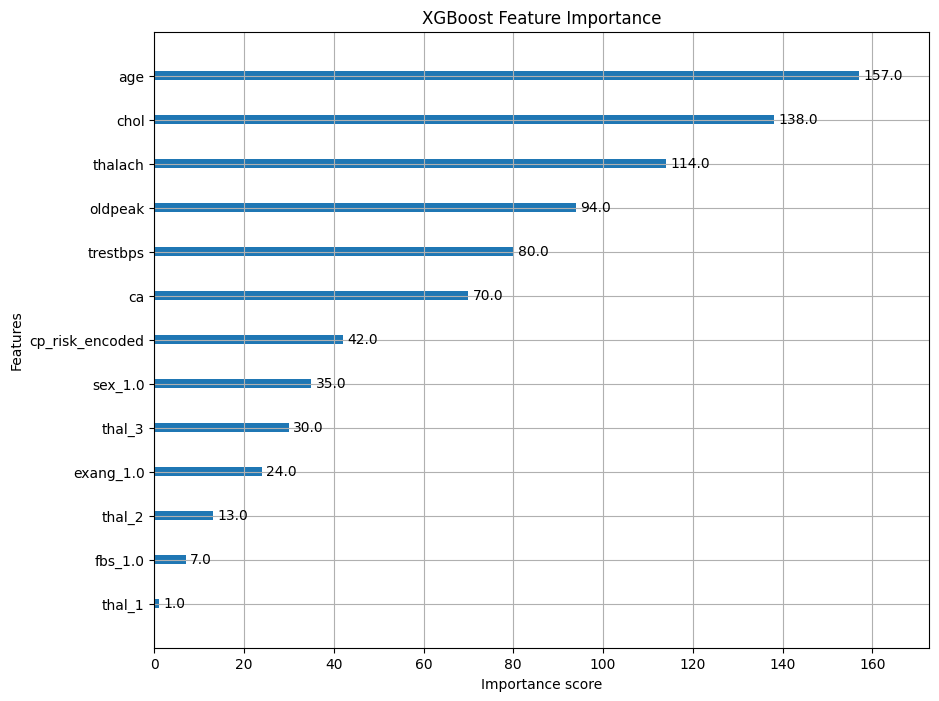

In [48]:
# XGBoost 시각화
from xgboost import plot_importance
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))
plot_importance(xgb_wrapper, ax=ax) # [cite: 2442]
plt.title("XGBoost Feature Importance")
plt.show()

# LightGBM

In [49]:
import lightgbm

print(lightgbm.__version__)

4.6.0


In [50]:
from lightgbm import LGBMClassifier, log_evaluation
from lightgbm import plot_importance
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

# 데이터 중복 체크 및 제거
df_final = df_final.drop_duplicates()
X_features = df_final.drop(columns=['target'])
y_label = df_final['target']

# 데이터 분리 (Train:Test = 8:2)
X_train, X_test, y_train, y_test = train_test_split(X_features, y_label, test_size=0.2, random_state=0)

# 학습 데이터에서 다시 검증 데이터(Validation) 분리
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=0)

# LightGBM 모델 설정 및 학습
lgbm_wrapper = LGBMClassifier(
    n_estimators=400,
    learning_rate=0.1,
    max_depth=3,
    early_stopping_rounds=50,
    verbose=-1,
    random_state=0
)

# 모델 학습 (조기 종료 적용)
evals = [(X_val, y_val)]
lgbm_wrapper.fit(X_tr, y_tr,eval_metric="logloss",eval_set=evals,callbacks=[log_evaluation(period=0)])

# 최종 평가 (처음 보는 X_test로 평가)
preds = lgbm_wrapper.predict(X_test)
pred_proba = lgbm_wrapper.predict_proba(X_test)[:, 1]

get_clf_eval(y_test, preds, pred_proba)


# 평가 지표 결과 #
오차 행렬
 [[48 10]
 [ 4 49]]
정확도: 0.8739, 정밀도: 0.8305, 재현율: 0.9245, F1: 0.8750, AUC: 0.9395


In [51]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd
import warnings

warnings.filterwarnings('ignore')

# 데이터 준비 및 분할
X_features = df_final.drop(columns=['target'])
y_label = df_final['target']
X_train, X_test, y_train, y_test = train_test_split(X_features, y_label, test_size=0.2, random_state=0)

# LGBMClassifier 객체 생성
lgbm_model = LGBMClassifier(n_estimators=100, random_state=0)

# 하이퍼파라미터 그리드 설정
param_grid = {
    'num_leaves': [31, 64],           # 최대 리프 개수
    'max_depth': [3, 5, 7],           # 트리의 최대 깊이
    'learning_rate': [0.01, 0.05, 0.1], # 학습률
    'min_child_samples': [10, 20, 30], # 리프 노드가 되기 위한 최소 데이터 수
    'colsample_bytree': [0.7, 0.8, 0.9] # 트리 구성 시 무작위 피처 선택 비율
}

# GridSearchCV 실행 (Stratified K-Fold 기반)
grid_cv = GridSearchCV(lgbm_model, param_grid=param_grid, cv=3, scoring='roc_auc', n_jobs=-1)
grid_cv.fit(X_train, y_train)

print(f'최적 하이퍼파라미터: {grid_cv.best_params_}')
print(f'최고 AUC 점수: {grid_cv.best_score_:.4f}')

# 최적 모델로 예측 및 평가
best_lgbm = grid_cv.best_estimator_
preds = best_lgbm.predict(X_test)
pred_proba = best_lgbm.predict_proba(X_test)[:, 1]

print('\n# LightGBM 최종 성능 평가 결과 #')
get_clf_eval(y_test, preds, pred_proba)

최적 하이퍼파라미터: {'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 7, 'min_child_samples': 10, 'num_leaves': 31}
최고 AUC 점수: 0.9755

# LightGBM 최종 성능 평가 결과 #

# 평가 지표 결과 #
오차 행렬
 [[49  9]
 [ 1 52]]
정확도: 0.9099, 정밀도: 0.8525, 재현율: 0.9811, F1: 0.9123, AUC: 0.9746


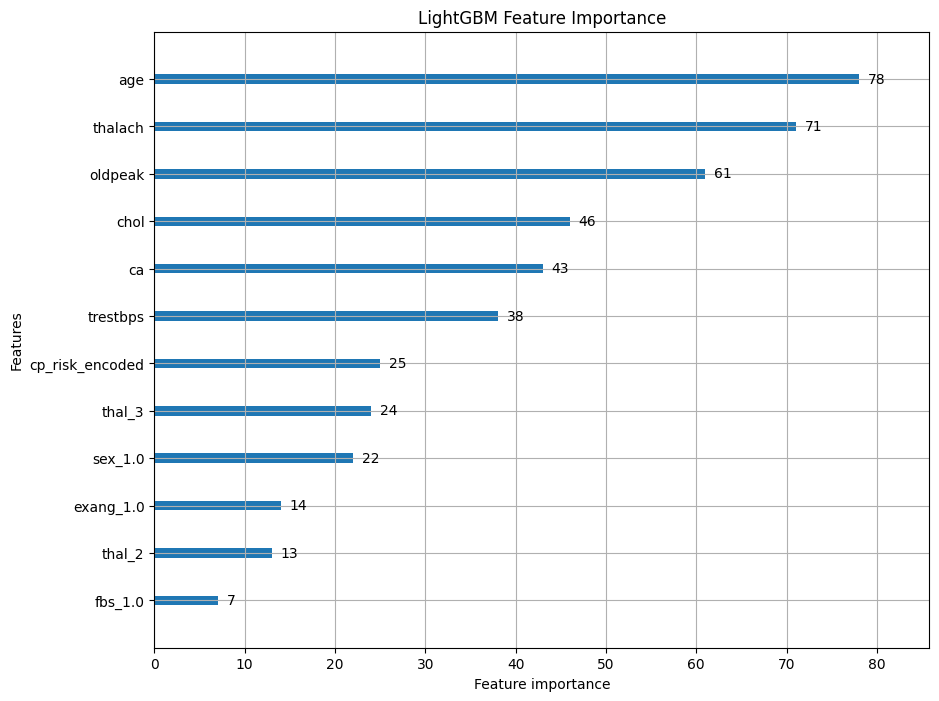

In [52]:
# LightGBM 시각화
from lightgbm import plot_importance
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))
plot_importance(lgbm_wrapper, ax=ax)
plt.title("LightGBM Feature Importance")
plt.show()

# **앙상블 학습 - Soft Voting 방식 채택**

In [53]:
from sklearn.ensemble import VotingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings('ignore')

# 데이터 준비 및 분할
X_features = df_final.drop(columns=['target'])
y_label = df_final['target']
X_train, X_test, y_train, y_test = train_test_split(X_features, y_label, test_size=0.2, random_state=0)

# GridSearchCV로 찾은 최적 파라미터를 각 모델에 적용
# (Random Forest 최적 파라미터)
rf_clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=7,
    min_samples_split=2,
    random_state=0
)

# (XGBoost 최적 파라미터)
xgb_clf = XGBClassifier(
    n_estimators=400, # 학습 횟수는 충분히 확보하도록 400으로 설정
    learning_rate=0.1,
    max_depth=7,
    min_child_weight=1,
    colsample_bytree=0.7,
    random_state=0
)

# (LightGBM 최적 파라미터)
lgbm_clf = LGBMClassifier(
    n_estimators=400,
    learning_rate=0.1,
    max_depth=7,
    num_leaves=31,
    min_child_samples=10,
    colsample_bytree=0.7,
    random_state=0
)

# Soft Voting 앙상블 모델 생성 (각 모델의 예측 확률 평균을 활용)
vo_clf = VotingClassifier(estimators=[('RF', rf_clf), ('XGB', xgb_clf), ('LGBM', lgbm_clf)],voting='soft')

# 최종 모델 학습 및 예측
vo_clf.fit(X_train, y_train)
preds = vo_clf.predict(X_test)
pred_proba = vo_clf.predict_proba(X_test)[:, 1]

print('\n# 앙상블 학습 최종 성능 평가 결과 #')
get_clf_eval(y_test, preds, pred_proba)


# 앙상블 학습 최종 성능 평가 결과 #

# 평가 지표 결과 #
오차 행렬
 [[49  9]
 [ 1 52]]
정확도: 0.9099, 정밀도: 0.8525, 재현율: 0.9811, F1: 0.9123, AUC: 0.9688


# **새로운 데이터와 비교 (실무 작업)**

In [54]:
new_test_df = pd.read_csv('newtest_heart.csv')
print(new_test_df.columns)

Index(['age', 'sex', 'chest_pain_type', 'resting_bp', 'cholestoral',
       'fasting_blood_sugar', 'restecg', 'max_hr', 'exang', 'oldpeak', 'slope',
       'num_major_vessels', 'thal', 'target'],
      dtype='object')


# 기존 코드와 동일하게 전처리 진행

In [55]:
import pandas as pd
import numpy as np

# 새로운 데이터 -> 기존 모델 이름
col_map = {
    'chest_pain_type': 'cp',
    'resting_bp': 'trestbps',
    'cholestoral': 'chol',
    'fasting_blood_sugar': 'fbs',
    'max_hr': 'thalach',
    'num_major_vessels': 'ca'
}

# 전처리 및 라벨 매칭 함수 정의
def transform_new_data_with_label(new_df, train_columns):
    df = new_df.copy()
    df = df.rename(columns=col_map)

    df = df[df['thal'] != 0].reset_index(drop=True)

    # Target추출
    if 'target' in df.columns:
        y_final = df['target']
    elif 'output' in df.columns:
        y_final = df['output']
    else:
        y_final = None

    # cp 위험도 그룹화 및 인코딩
    def cp_risk_group(cp):
        if cp == 0: return 'high_risk'
        elif cp in [1, 2]: return 'mid_risk'
        else: return 'low_risk'

    df['cp_risk_group'] = df['cp'].apply(cp_risk_group)
    risk_mapping = {'low_risk': 0, 'mid_risk': 1, 'high_risk': 2}
    df['cp_risk_encoded'] = df['cp_risk_group'].map(risk_mapping)

    # 범주형 변수 인코딩
    df = pd.get_dummies(df, columns=['restecg', 'thal'], dtype=float)
    df = pd.get_dummies(df, columns=['sex', 'fbs', 'exang'], drop_first=True)

    # 칼럼 순서 맞추기 (X_train.columns 기준)
    drop_cols = ['cp', 'cp_risk_group', 'target', 'output', 'chest_pain_type', 'resting_bp', 'cholestoral', 'fasting_blood_sugar', 'max_hr', 'num_major_vessels']
    X_final = df.drop(columns=[c for c in drop_cols if c in df.columns], errors='ignore')
    X_final = X_final.reindex(columns=train_columns, fill_value=0)

    return X_final, y_final

In [56]:
import pandas as pd
import numpy as np

# 학습 시 사용했던 컬럼 리스트 추출
model_features = X_train.columns.tolist()

X_new_final, y_new_matched = transform_new_data_with_label(new_test_df, model_features)

# 학습 데이터와 새로운 데이터를 하나로 합친 후 비교
X_train_temp = X_train.copy()
X_new_temp = X_new_final.copy()
X_new_temp['target_internal'] = y_new_matched.values

# X_train에 존재하는 행이 X_new_temp에도 있는지 확인하여 중복 제거
merged = X_new_temp.drop('target_internal', axis=1).merge(
    X_train_temp,
    how='left',
    indicator=True
)

# 'left_only'인 것만 추출 (순수한 새로운 데이터)
pure_indices = merged[merged['_merge'] == 'left_only'].index

X_pure = X_new_final.iloc[pure_indices]
y_pure = y_new_matched.iloc[pure_indices]

print(f"전체 새로운 데이터: {len(X_new_final)}개")
print(f"중복 제거 후 순수 데이터: {len(X_pure)}개")

# 순수 데이터로 최종 지표 확인
if len(X_pure) > 0:
    print("      \n# 중복 제거 후: 앙상블 모델 최종 결과 #      ")
    pure_preds = vo_clf.predict(X_pure)
    pure_pred_proba = vo_clf.predict_proba(X_pure)[:, 1]
    get_clf_eval(y_pure, pure_preds, pure_pred_proba)
else:
    print("모든 데이터가 중복되었습니다. 새로운 데이터셋이 학습 데이터와 100% 일치합니다.")

전체 새로운 데이터: 301개
중복 제거 후 순수 데이터: 256개
      
# 중복 제거 후: 앙상블 모델 최종 결과 #      

# 평가 지표 결과 #
오차 행렬
 [[108  22]
 [  0 126]]
정확도: 0.9141, 정밀도: 0.8514, 재현율: 1.0000, F1: 0.9197, AUC: 0.9896


# **PCA 진행**

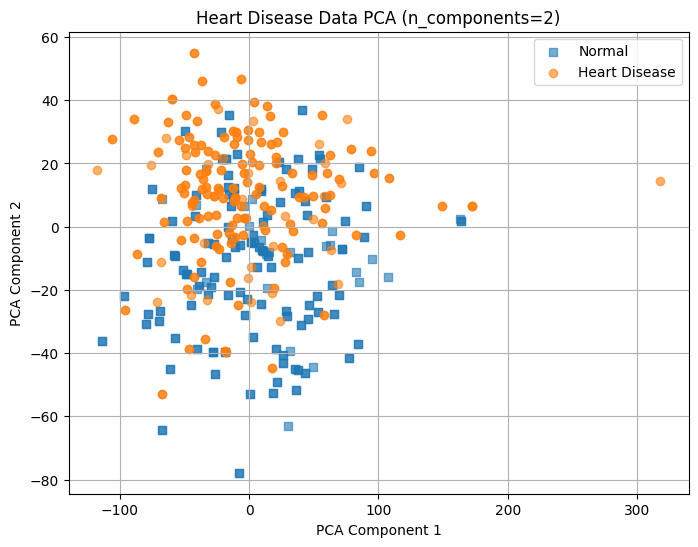

PCA Component별 변동성 비율: [0.73394521 0.16032151]
전체 변동성 합계: 0.8943

[원본 데이터 성능]
개별 Fold 정확도: [0.9402 0.9348 0.9399]
평균 정확도: 0.9383

95% 변동성 유지를 위한 PCA 성분 개수: 3개

[PCA 변환 데이터 성능]
개별 Fold 정확도: [0.875  0.8424 0.8634]
평균 정확도: 0.8603


In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import cross_val_score

# 데이터 준비
X_features = df_final.drop(columns=['target'])
y_target = df_final['target'].astype(int)

# PCA 변환 및 시각화
pca = PCA(n_components=2)
pca_indices = pca.fit_transform(X_features)

pca_columns = ['pca_component_1', 'pca_component_2']
df_pca = pd.DataFrame(pca_indices, columns=pca_columns)
df_pca['target'] = y_target.values

# 시각화: 심장병 유무에 따른 분포
markers = ['s', 'o'] # 0: 정상, 1: 심장병 발생
labels = ['Normal', 'Heart Disease']

plt.figure(figsize=(8, 6))
for i, marker in enumerate(markers):
    x_data = df_pca[df_pca['target'] == i]['pca_component_1']
    y_data = df_pca[df_pca['target'] == i]['pca_component_2']
    plt.scatter(x_data, y_data, marker=marker, label=labels[i], alpha=0.6)

plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('Heart Disease Data PCA (n_components=2)')
plt.legend()
plt.grid(True)
plt.show()

# 주성분별 변동성(분산) 비율 확인
print('PCA Component별 변동성 비율:', pca.explained_variance_ratio_)
print('전체 변동성 합계: {0:.4f}'.format(np.sum(pca.explained_variance_ratio_)))

# 모델 성능 비교 (원본 최종 Soft Voting 앙상블 모델 vs PCA 변환)
rf_clf = RandomForestClassifier(n_estimators=100, max_depth=7, random_state=0)
xgb_clf = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=7, random_state=0)
lgbm_clf = LGBMClassifier(n_estimators=100, learning_rate=0.1, max_depth=7, random_state=0)

vo_clf = VotingClassifier(
    estimators=[('RF', rf_clf), ('XGB', xgb_clf), ('LGBM', lgbm_clf)],
    voting='soft')

# 원본 데이터 교차 검증 (CV=3)
scores_orig = cross_val_score(vo_clf, X_features, y_target, scoring='accuracy', cv=3)
print('\n[원본 데이터 성능]')
print('개별 Fold 정확도:', np.round(scores_orig, 4))
print('평균 정확도: {0:.4f}'.format(np.mean(scores_orig)))

# PCA 변환 데이터 교차 검증 (변동성의 95%를 설명하는 성분 개수 사용)
pca_95 = PCA(n_components=0.95)
df_pca_95 = pca_95.fit_transform(X_features)
print(f'\n95% 변동성 유지를 위한 PCA 성분 개수: {df_pca_95.shape[1]}개\n')

scores_pca = cross_val_score(vo_clf, df_pca_95, y_target, scoring='accuracy', cv=3)
print('[PCA 변환 데이터 성능]')
print('개별 Fold 정확도:', np.round(scores_pca, 4))
print('평균 정확도: {0:.4f}'.format(np.mean(scores_pca)))

# **K-Means & GMM 진행**

# K-Means 군집별 Target 분포 #
target  kmeans_cluster
0       2                 125
        1                  84
        0                  46
1       1                 127
        2                 123
        0                  46
Name: count, dtype: int64

# GMM 군집별 Target 분포 #
target  gmm_cluster
0       2              223
        1               24
        0                8
1       2              274
        1               18
        0                4
Name: count, dtype: int64


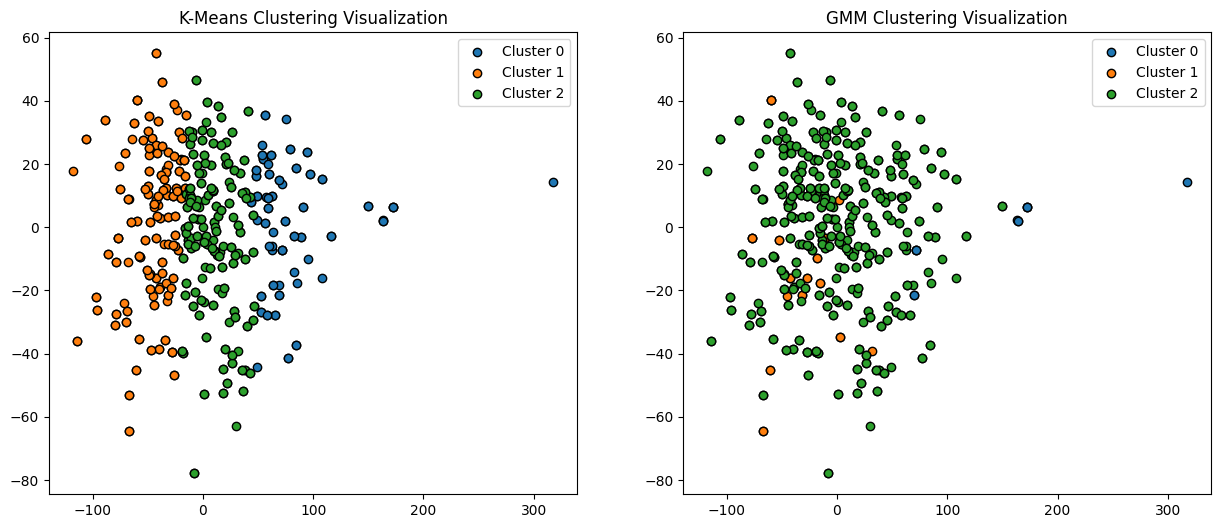


[성능 비교 결과]
1. 원본 데이터 앙상블 정확도: 0.9383
2. K-Means 군집 변수 추가 후 정확도: 0.9292
3. GMM 군집 변수 추가 후 정확도: 0.9292


In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import VotingClassifier

# 데이터 준비
X_features = df_final.drop(columns=['target'])
y_target = df_final['target'].astype(int)

# K-Means 클러스터링
# 심장병 유무(0,1) 또는 위험도 단계(0,1,2)를 고려하여 n_cluster 설정
kmeans = KMeans(n_clusters=3, init='k-means++', max_iter=300, random_state=0)
kmeans_labels = kmeans.fit_predict(X_features)

# GMM 클러스터링
gmm = GaussianMixture(n_components=3, random_state=0)
gmm_labels = gmm.fit_predict(X_features)

# 분석용 DataFrame 생성 및 군집 결과 확인
cluster_df = X_features.copy()
cluster_df['kmeans_cluster'] = kmeans_labels
cluster_df['gmm_cluster'] = gmm_labels
cluster_df['target'] = y_target.values

print("# K-Means 군집별 Target 분포 #")
print(cluster_df.groupby(['target'])['kmeans_cluster'].value_counts())
print("\n# GMM 군집별 Target 분포 #")
print(cluster_df.groupby(['target'])['gmm_cluster'].value_counts())

# 시각화 (PCA로 2차원 축소 후 군집 결과 확인)
pca = PCA(n_components=2)
pca_transformed = pca.fit_transform(X_features)
cluster_df['pca_x'] = pca_transformed[:, 0]
cluster_df['pca_y'] = pca_transformed[:, 1]

fig, (ax1, ax2) = plt.subplots(figsize=(15, 6), ncols=2)

# K-Means 시각화
for label in np.unique(kmeans_labels):
    target_cluster = cluster_df[cluster_df['kmeans_cluster'] == label]
    ax1.scatter(x=target_cluster['pca_x'], y=target_cluster['pca_y'], edgecolors='k', label=f'Cluster {label}')
ax1.set_title('K-Means Clustering Visualization')
ax1.legend()

# GMM 시각화
for label in np.unique(gmm_labels):
    target_cluster = cluster_df[cluster_df['gmm_cluster'] == label]
    ax2.scatter(x=target_cluster['pca_x'], y=target_cluster['pca_y'], edgecolors='k', label=f'Cluster {label}')
ax2.set_title('GMM Clustering Visualization')
ax2.legend()
plt.show()

# 새로운 Feature로서의 성능 검증

# 원본 데이터 성능
score_orig = cross_val_score(vo_clf, X_features, y_target, cv=3).mean()

# K-Means 군집 feature 추가 후 성능
X_kmeans = X_features.copy()
X_kmeans['cluster_id'] = kmeans_labels
score_kmeans = cross_val_score(vo_clf, X_kmeans, y_target, cv=3).mean()

# GMM 군집 feature 추가 후 성능
X_gmm = X_features.copy()
X_gmm['cluster_id'] = gmm_labels
score_gmm = cross_val_score(vo_clf, X_gmm, y_target, cv=3).mean()

print(f"\n[성능 비교 결과]")
print(f"1. 원본 데이터 앙상블 정확도: {score_orig:.4f}")
print(f"2. K-Means 군집 변수 추가 후 정확도: {score_kmeans:.4f}")
print(f"3. GMM 군집 변수 추가 후 정확도: {score_gmm:.4f}")

# **실험 전과 후 모델 성능 비교**

Case A: 원본 최종 앙상블 완료 (Acc: 0.9383, Recall: 0.9359)
Case B: PCA 적용 완료 (Acc: 0.8603, Recall: 0.8717)
Case C: Cluster 적용 완료 (Acc: 0.9256, Recall: 0.9189)

       [최종 비지도 학습 적용 성능 비교표]       


,Case,Feature_Count,Accuracy,Recall
0,Case A: 원본 최종 앙상블,16,0.9383,0.9359
1,Case B: PCA 적용,3,0.8603,0.8717
2,Case C: Cluster 적용,18,0.9256,0.9189


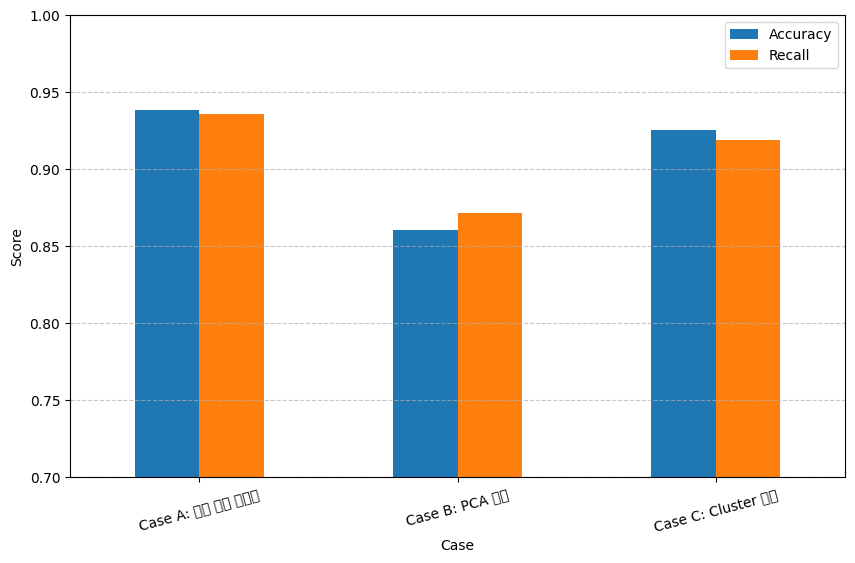

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import cross_validate
from sklearn.metrics import accuracy_score, recall_score

# 모델 설정 (기존 최적화 하이퍼파라미터 적용)
rf_best = RandomForestClassifier(n_estimators=100, max_depth=7, random_state=0)
xgb_best = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=7, random_state=0)
lgbm_best = LGBMClassifier(n_estimators=100, learning_rate=0.1, max_depth=7, random_state=0)

# 최종 앙상블 모델 (Soft Voting)
vo_clf = VotingClassifier(
    estimators=[('RF', rf_best), ('XGB', xgb_best), ('LGBM', lgbm_best)],
    voting='soft')

# 성능 기록을 위한 리스트
results = []

def evaluate_pipeline(X, y, case_name):
    """3개 폴드 교차 검증으로 정확도와 재현율 측정"""
    cv_results = cross_validate(vo_clf, X, y, cv=3, scoring=['accuracy', 'recall'])
    acc = np.mean(cv_results['test_accuracy'])
    rec = np.mean(cv_results['test_recall'])

    results.append({
        'Case': case_name,
        'Feature_Count': X.shape[1],
        'Accuracy': round(acc, 4),
        'Recall': round(rec, 4)
    })
    print(f"{case_name} 완료 (Acc: {acc:.4f}, Recall: {rec:.4f})")

# [Case A] 원본 데이터
X_features = df_final.drop(columns=['target'])
y_target = df_final['target'].astype(int)
evaluate_pipeline(X_features, y_target, "Case A: Soft Voting Ensemble")

# [Case B] PCA 적용 (차원 축소)
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_features)
evaluate_pipeline(pd.DataFrame(X_pca), y_target, "Case B: PCA")

# [Case C] Clustering 적용 (K-means/GMM Feature 추가)
X_clustered = X_features.copy()

# K-Means로 군집 정보 생성
kmeans = KMeans(n_clusters=3, random_state=0)
X_clustered['cluster_id'] = kmeans.fit_predict(X_features)

# GMM으로 군집 정보 생성 (하나 더 추가해서 성능 확인)
gmm = GaussianMixture(n_components=3, random_state=0)
X_clustered['gmm_id'] = gmm.fit_predict(X_features)

evaluate_pipeline(X_clustered, y_target, "Case C: Cluster (K-means/GMM)")

# 최종 결과 비교표
final_report = pd.DataFrame(results)
print("\n       [최종 비지도 학습 적용 성능 비교표]       ")
display(final_report)

# 결과 시각화
final_report.set_index('Case')[['Accuracy', 'Recall']].plot(kind='bar', figsize=(10, 6))
plt.title('')
plt.ylabel('Score')
plt.xticks(rotation=15)
plt.ylim(0.7, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()